<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/>

# M07 Rapid Machine Learning

---
<small>© 2026 Decoded Limited. All rights reserved. Website: https://decoded.com </small>

### Rapid Machine Learning with PyCaret
Welcome! In this notebook, we will use **PyCaret** to rapidly build, tune, and deploy machine learning models. 

We are taking it a step further than basic scripts: we will build a **reusable Python module** capable of handling *both* **Classification** and **Regression** tasks, use **scikit-learn** for robust data splitting, and then save (pickle) our pipelines for future use.

**PyCaret** is designed to make this incredibly easy. In this notebook, we will walk through the core PyCaret workflow:
1. **Setup:** Prepare the data.
2. **Compare:** Rapidly test multiple algorithms to find the best one.
3. **Tune:** Optimize the winning algorithm's parameters.
4. **Deploy:** Save the final model for real-world use.

In [12]:
# Install pycaret (uncomment the line below if running for the first time in this environment)
# !pip install pycaret

## 1. The Data: Loading and Splitting
We need two datasets to experiment workflows studied in this accelerator programme:
1. **Juice (Classification):** Predicting customer beverage brand preferences.
2. **Insurance (Regression):** Predicting medical charges based on patient attributes.

We will use `scikit-learn` to cleanly split off 20% of our data as an "unseen" holdout set to test our final loaded pipelines.

In [13]:
from pycaret.datasets import get_data
from sklearn.model_selection import train_test_split

# 1. Classification Data
clf_data = get_data('juice')
clf_train, clf_unseen = train_test_split(clf_data, test_size=0.2, random_state=42)

# Reset indices for clean dataframes
clf_train.reset_index(drop=True, inplace=True)
clf_unseen.reset_index(drop=True, inplace=True)

# 2. Regression Data
reg_data = get_data('insurance')
reg_train, reg_unseen = train_test_split(reg_data, test_size=0.2, random_state=42)

# Reset indices for clean dataframes
reg_train.reset_index(drop=True, inplace=True)
reg_unseen.reset_index(drop=True, inplace=True)

print(f"Classification Data Setup: {clf_train.shape} train, {clf_unseen.shape} unseen")
print(f"Regression Data Setup: {reg_train.shape} train, {reg_unseen.shape} unseen")

,Id,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,1,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,2,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,3,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,4,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,5,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Classification Data Setup: (856, 19) train, (214, 19) unseen
Regression Data Setup: (1070, 7) train, (268, 7) unseen


## 2 Building the rapid model build pipeline

#### Step 1: Setup the Environment
The `setup()` function initializes the training environment and creates the transformation pipeline. It automatically infers data types and prepares everything for modeling behind the scenes.

In [19]:
from pycaret.classification import *

# We tell PyCaret what dataset to use and which column is our target.
# session_id ensures our results are reproducible (like a random seed).
exp_setup = setup(data=clf_train, target='Purchase', session_id=123, fold =5, n_jobs=1 )

,Description,Value
0,Session id,123
1,Target,Purchase
2,Target type,Binary
3,Target mapping,"CH: 0, MM: 1"
4,Original data shape,"(856, 19)"
5,Transformed data shape,"(856, 19)"
6,Transformed train set shape,"(599, 19)"
7,Transformed test set shape,"(257, 19)"
8,Numeric features,17
9,Categorical features,1


#### Step 2: Rapid Model Build (`compare_models`)
Instead of guessing which algorithm will work best, we use `compare_models()`. This function trains and evaluates a library of over 15 standard machine learning algorithms using cross-validation, and ranks them by performance.

In [20]:
import psutil
import os

# Check CPU usage
print(f"CPU Usage: {psutil.cpu_percent()}%")

# Check Memory usage of the current process (the Notebook itself)
process = psutil.Process(os.getpid())
print(f"Memory used by this Notebook: {process.memory_info().rss / 1024 / 1024:.2f} MB")

CPU Usage: 0.4%
Memory used by this Notebook: 290.29 MB


In [21]:
# This will output a leaderboard of models. 
# It returns the top-performing model object.
select_models = ['lr','dt','rf','mlp','dummy']


print(f"CPU Usage: {psutil.cpu_percent()}%")
best_model = compare_models(include=select_models, budget_time = 0.3)

# Check Memory usage of the current process (the Notebook itself)
process = psutil.Process(os.getpid())
print(f"Memory used by this Notebook: {process.memory_info().rss / 1024 / 1024:.2f} MB")


CPU Usage: 0.1%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8046,0.8914,0.8046,0.8059,0.8027,0.5834,0.5876,0.0620
rf,Random Forest Classifier,0.8013,0.8822,0.8013,0.8036,0.7998,0.5786,0.5826,0.0860
dt,Decision Tree Classifier,0.7513,0.7352,0.7513,0.7545,0.7489,0.4726,0.4781,0.0240
mlp,MLP Classifier,0.7077,0.8095,0.7077,0.7507,0.6707,0.3345,0.3839,1.3400
dummy,Dummy Classifier,0.6110,0.5000,0.6110,0.3734,0.4635,0.0000,0.0000,0.0240


Memory used by this Notebook: 290.29 MB


#### Step 3: Inspecting Model Parameters
What exactly is `best_model`? It is an actual scikit-learn (or similar) model object with default parameters. Let's print it to see its internal settings.

In [22]:
print("--- Best Baseline Model Parameters ---")
print(best_model)

--- Best Baseline Model Parameters ---
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


#### Step 4: Tune the Model
Our `best_model` did well, but it is just using default settings. The `tune_model()` function automatically searches through a grid of hyperparameters to squeeze out even better performance.

In [23]:
# Tune the hyperparameters of the best model
tuned_model = tune_model(best_model, n_iter=3)

# Let's look at the parameters now. Notice how they have changed from the baseline!
print("\n--- Tuned Model Parameters ---")
print(tuned_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8333,0.9107,0.8333,0.8321,0.8317,0.6416,0.6432
1,0.8333,0.9164,0.8333,0.8330,0.8309,0.6421,0.6458
2,0.8083,0.8648,0.8083,0.8069,0.8071,0.5932,0.5940
3,0.8167,0.8834,0.8167,0.8167,0.8167,0.6153,0.6153
4,0.7899,0.8868,0.7899,0.7961,0.7916,0.5658,0.5679
Mean,0.8163,0.8924,0.8163,0.8170,0.8156,0.6116,0.6132
Std,0.0164,0.0189,0.0164,0.0143,0.0151,0.0293,0.0296


Fitting 5 folds for each of 3 candidates, totalling 15 fits

--- Tuned Model Parameters ---
LogisticRegression(C=7.863, class_weight={}, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


#### Step 5: Deploy (Save the Model)
Once we are happy with our tuned model, we need to save it so we can use it in a real application (like a web app or an automated script). 

`save_model()` bundles the tuned model AND the entire data preparation pipeline into a single downloadable file.

In [24]:
# Save the model to your hard drive
save_model(tuned_model, 'my_first_deployment_pipeline')

print("\nSuccess! Your model is now saved as 'my_first_deployment_pipeline.pkl' and ready for the real world.")

Transformation Pipeline and Model Successfully Saved

Success! Your model is now saved as 'my_first_deployment_pipeline.pkl' and ready for the real world.


### 3. Model Pickling & Inference on test data
Finally, we save both pipelines, load them back up using the respective PyCaret function, and make predictions on the unseen data we set aside earlier.

In [25]:
# 1. Load the saved pipeline
# Notice we don't need to add the '.pkl' extension, PyCaret handles it!
print("Loading saved pipeline...")
loaded_pipeline = load_model('my_first_deployment_pipeline')

Loading saved pipeline...
Transformation Pipeline and Model Successfully Loaded


In [26]:
# 2. Make predictions on the test/holdout data
# By default, if we don't pass a new dataframe to the 'data' parameter, 
# PyCaret automatically uses the test set it created during setup().
print("\nGenerating predictions on the test data...")
predictions = predict_model(loaded_pipeline)


Generating predictions on the test data...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.8521,0.9095,0.8521,0.8514,0.8509,0.6844,0.6859


In [27]:
# 3. View the results
# PyCaret adds two new columns to the end of the dataframe:
# 'prediction_label' (the predicted class) and 'prediction_score' (the probability of that class)
display(predictions[['Purchase', 'prediction_label', 'prediction_score']].head(10))

,Purchase,prediction_label,prediction_score
45,MM,CH,0.7466
340,MM,MM,0.7340
224,CH,CH,0.9395
406,CH,CH,0.9312
506,CH,CH,0.9901
488,CH,CH,0.9053
802,CH,MM,0.9314
159,MM,CH,0.5060
760,CH,CH,0.8875
89,MM,MM,0.9774


### 4 Visualising Model Performance (Confusion Matrix)
Numbers are great, but visuals are better. We want to see exactly how many predictions our model got right, and where it got "confused" (e.g., predicting Citrus Hill when the customer actually bought Minute Maid).

PyCaret's `plot_model()` function automatically evaluates your trained model on the holdout test set and generates beautiful interactive charts. Let's look at the Confusion Matrix.

Generating Confusion Matrix...


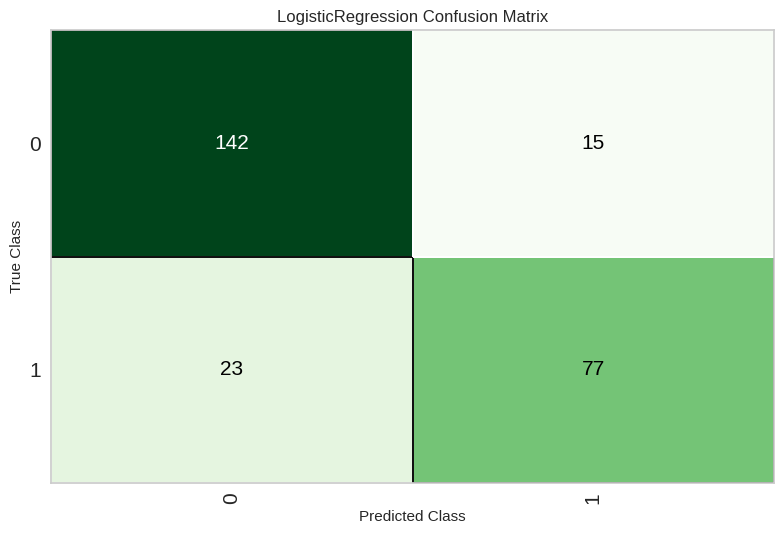

In [28]:
# Plot the confusion matrix for our tuned model
print("Generating Confusion Matrix...")
plot_model(tuned_model, plot='confusion_matrix')

# Note: You can also explore other plots just by changing the 'plot' parameter!
# Try uncommenting the lines below:
# plot_model(tuned_model, plot='feature')  # Feature Importance
# plot_model(tuned_model, plot='auc')      # ROC-AUC Curve

## 5. The Reusable Module (Classification & Regression) (Optional)
To make our code clean and reusable, we will build . By using PyCaret's modern Object-Oriented API (`ClassificationExperiment` and `RegressionExperiment`), we can easily switch between task types without global state conflicts.

File: `readme.md`

```bash
rapid-ml-project/
│
├── data/                   # Store local datasets here
│
├── models/                 # Your saved PyCaret pipelines (.pkl) will go here
│
├── notebooks/              # Jupyter notebooks for EDA and initial experimentation
│   ├── pycaret_eda_tutorial.ipynb
│   └── pycaret_mlflow_tutorial.ipynb
│
├── src/                    # Source code for your reusable ML modules
│   ├── __init__.py         # Makes 'src' a recognisable Python module
│   └── ml_pipeline.py      # The custom PyCaret functions we built
│
├── main.py                 # The execution script that runs the pipeline
├── requirements.txt        # List of required Python packages
└── README.md               # The manual for your project

```

### 1. The Core Module (`ml_pipeline.py`)

This script contains our reusable functions. Notice how we return the `exp` (the PyCaret experiment instance) alongside the model so that we can pass it into our saving and predicting functions later.

```python
from pycaret.classification import ClassificationExperiment
from pycaret.regression import RegressionExperiment

def build_and_tune_model(data, target_col, task_type='classification', experiment_name=None, session_id=123):
    """
    Initializes PyCaret, compares models, tunes the best one, and logs to MLflow.
    Returns the tuned model and the active PyCaret experiment instance.
    """
    print(f"\n--- Starting {task_type.upper()} Pipeline ---")
    
    # 1. Initialize the correct PyCaret Experiment
    if task_type.lower() == 'classification':
        exp = ClassificationExperiment()
        sort_metric = 'Accuracy'
    elif task_type.lower() == 'regression':
        exp = RegressionExperiment()
        sort_metric = 'R2'
    else:
        raise ValueError("task_type must be either 'classification' or 'regression'")
        
    # 2. Setup with MLflow tracking enabled
    exp_name = experiment_name or f"rapidml_{task_type}_experiment"
    exp.setup(
        data=data, 
        target=target_col, 
        session_id=session_id, 
        log_experiment=True, 
        experiment_name=exp_name,
        verbose=False
    )
    
    # 3. Compare Baseline Models
    print(f"Finding best baseline model (optimizing for {sort_metric})...")
    best_model = exp.compare_models(sort=sort_metric)
    
    # 4. Tune the Best Model
    print("Tuning the best model...")
    tuned_model = exp.tune_model(best_model)
    
    print("Pipeline Complete!")
    return tuned_model, exp


def save_pipeline(exp_instance, model, filename):
    """Pickles the model and the entire preprocessing pipeline."""
    exp_instance.save_model(model, filename)
    print(f"Model and pipeline successfully saved to {filename}.pkl")


def load_and_predict(exp_instance, filename, unseen_data):
    """Loads a saved pipeline and generates predictions on new data."""
    print(f"Loading pipeline from {filename}.pkl...")
    loaded_pipeline = exp_instance.load_model(filename)
    
    print("Generating predictions...")
    predictions = exp_instance.predict_model(loaded_pipeline, data=unseen_data)
    return predictions

```



### 2. The execution script (`main.py`)

This script imports the functions we just built and uses them to process our data end-to-end. This makes your execution code incredibly readable!

```python
import pandas as pd
from pycaret.datasets import get_data
from sklearn.model_selection import train_test_split

# Import our custom functions (assuming they are saved in ml_pipeline.py)
# from ml_pipeline import build_and_tune_model, save_pipeline, load_and_predict

if __name__ == "__main__":
    # --- 1. DATA PREPARATION ---
    print("Loading and splitting data...")
    juice_data = get_data('juice', verbose=False)
    clf_train, clf_unseen = train_test_split(juice_data, test_size=0.05, random_state=42)
    
    insurance_data = get_data('insurance', verbose=False)
    reg_train, reg_unseen = train_test_split(insurance_data, test_size=0.05, random_state=42)

    # --- 2. CLASSIFICATION WORKFLOW ---
    clf_model, clf_exp = build_and_tune_model(
        data=clf_train, 
        target_col='Purchase', 
        task_type='classification', 
        experiment_name='Juice_Functions_Exp'
    )
    
    save_pipeline(clf_exp, clf_model, 'functional_clf_pipeline')
    
    clf_predictions = load_and_predict(clf_exp, 'functional_clf_pipeline', clf_unseen)
    print("\nClassification Predictions:")
    print(clf_predictions[['Purchase', 'prediction_label', 'prediction_score']].head())

    # --- 3. REGRESSION WORKFLOW ---
    reg_model, reg_exp = build_and_tune_model(
        data=reg_train, 
        target_col='charges', 
        task_type='regression',
        experiment_name='Insurance_Functions_Exp'
    )
    
    save_pipeline(reg_exp, reg_model, 'functional_reg_pipeline')
    
    reg_predictions = load_and_predict(reg_exp, 'functional_reg_pipeline', reg_unseen)
    print("\nRegression Predictions:")
    print(reg_predictions[['charges', 'prediction_label']].head())

```

